In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
demographic = pd.read_csv('cleaned dataset/api_data_aadhar_demographic.csv')

In [15]:

# Proxy for Workforce / Migration Churn
col_adults = 'age 17 and above'   
# Proxy for School Enrolment / Family Retention   
col_kids = 'age between 5 and 17'          

In [16]:
district_profile = demographic.groupby('district')[[ col_kids , col_adults ]].sum().reset_index()
display(district_profile.head())

,district,age between 5 and 17,age 17 and above
0,5Th Cross,0,1
1,Adilabad,9009,66292
2,Agar Malwa,965,8919
3,Agra,18477,157476
4,Ahilyanagar,200,2218


In [17]:

# We calculate how far each district deviates from the national average(by z-score)

district_profile['adults_z'] = (district_profile[col_adults] - district_profile[col_adults].mean()) / district_profile[col_adults].std()

district_profile['kids_z'] = (district_profile[col_kids] - district_profile[col_kids].mean()) / district_profile[col_kids].std()

display(district_profile.head())


,district,age between 5 and 17,age 17 and above,adults_z,kids_z
0,5Th Cross,0,1,-0.867747,-0.900705
1,Adilabad,9009,66292,0.250857,0.540849
2,Agar Malwa,965,8919,-0.717264,-0.746293
3,Agra,18477,157476,1.789510,2.055848
4,Ahilyanagar,200,2218,-0.830337,-0.868703


In [19]:

def classify_district(row):
    
    high_outward_mig = row['adults_z'] > 0
    high_child_enrol = row['kids_z'] > 0

    if high_outward_mig and not high_child_enrol:
        return 'Ghost Village (Risk)'  # Lots of adults moving, NO kids
    elif high_outward_mig and high_child_enrol:
        return 'Boom Town'             # Lots of adults AND kids (Growing)
    elif not high_outward_mig and not high_child_enrol:
        return 'Stagnant'              # Quiet, aging, low activity
    else:
        return 'Nursery'               # Low adult movement, but high kid retention

district_profile['Category'] = district_profile.apply(classify_district, axis=1)
display(district_profile.head())  

,district,age between 5 and 17,age 17 and above,adults_z,kids_z,Category
0,5Th Cross,0,1,-0.867747,-0.900705,Stagnant
1,Adilabad,9009,66292,0.250857,0.540849,Boom Town
2,Agar Malwa,965,8919,-0.717264,-0.746293,Stagnant
3,Agra,18477,157476,1.789510,2.055848,Boom Town
4,Ahilyanagar,200,2218,-0.830337,-0.868703,Stagnant


In [21]:
district_profile.to_csv('csv for power bi/district_migration_profile.csv', index=False)
print("File 'district_migration_profile.csv' generated.")

File 'district_migration_profile.csv' generated.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24980\670646185.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  at_risk['risk_severity'] = at_risk['adults_z'] - at_risk['kids_z']


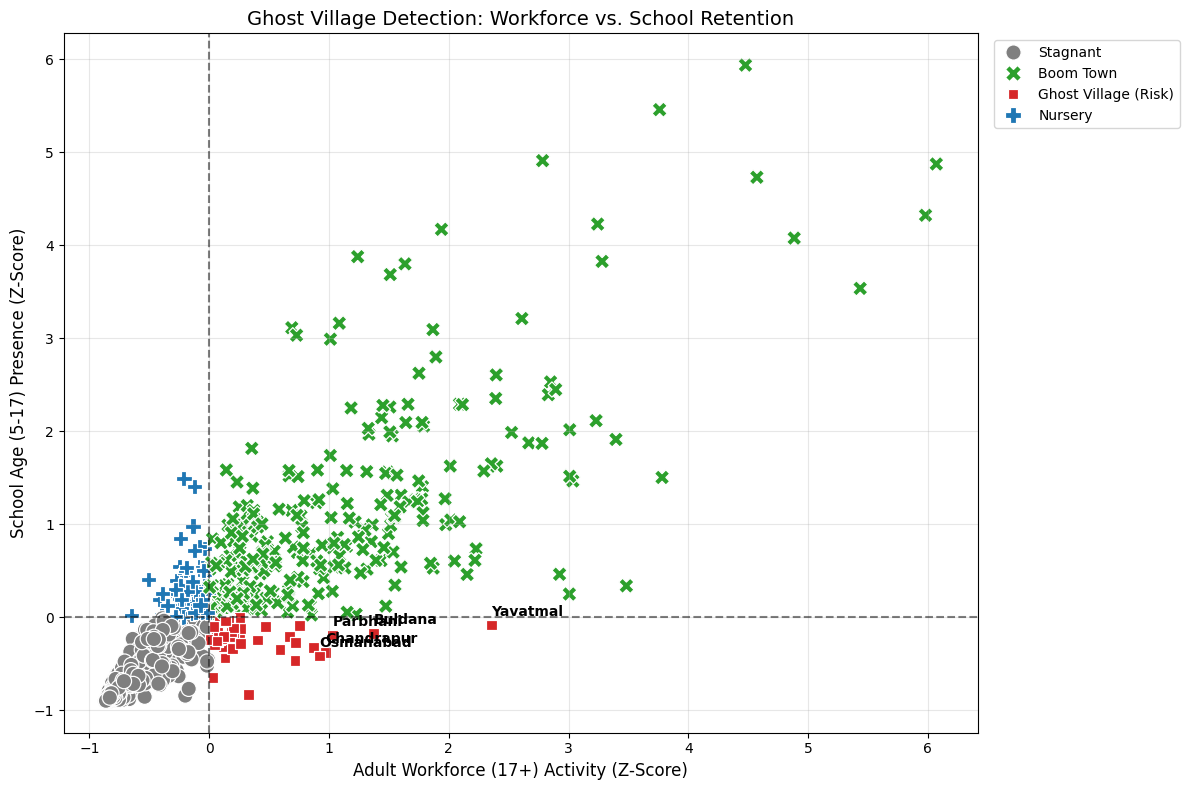

In [20]:
# 5. Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=district_profile, 
    x='adults_z', 
    y='kids_z', 
    hue='Category',
    style='Category',
    s=120,
    palette={'Ghost Village (Risk)': '#d62728',  # Red
             'Boom Town': '#2ca02c',             # Green
             'Stagnant': '#7f7f7f',              # Grey
             'Nursery': '#1f77b4'}               # Blue
)

# Quadrant Lines
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Labels
plt.title('Ghost Village Detection: Workforce vs. School Retention', fontsize=14)
plt.xlabel('Adult Workforce (17+) Activity (Z-Score)', fontsize=12)
plt.ylabel('School Age (5-17) Presence (Z-Score)', fontsize=12)

# Label top risk districts
at_risk = district_profile[district_profile['Category'] == 'Ghost Village (Risk)']
# Sort by lowest kid ratio relative to adults
at_risk['risk_severity'] = at_risk['adults_z'] - at_risk['kids_z'] 
top_risk = at_risk.sort_values(by='risk_severity', ascending=False).head(5)

for i, txt in enumerate(top_risk['district']):
    plt.text(top_risk['adults_z'].iloc[i], top_risk['kids_z'].iloc[i]+0.1, txt, color='black', weight='bold')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

For the "Ghost Village" Analysis, you need to build a Scatter Chart (also known as a Quadrant Chart).This is the standard business graph for comparing two variables to find outliers.1. The Main Visual: The Quadrant Scatter PlotVisual Type: Scatter Chart (Select the icon with dots scattered on an X-Y axis).X-Axis: Drag adults_z here (This is your Workforce Activity).Y-Axis: Drag kids_z here (This is your School Presence).Legend: Drag Category here (This will color-code the dots: Red for Ghost Village, Green for Boom Town).Details: Drag district here (So when you hover over a dot, it tells you the district name).2. The "Magic" Setup (Making the Crosshairs)To make it look like a matrix and not just random dots, you must add reference lines at 0.Go to the Analytics Pane (The magnifying glass icon next to the paintbrush).Find X-Axis Constant Line $\rightarrow$ Add Line $\rightarrow$ Set value to 0.Find Y-Axis Constant Line $\rightarrow$ Add Line $\rightarrow$ Set value to 0.Result: This draws a "Cross" in the middle of your graph, clearly dividing the districts into the 4 zones.3. What the Result Will Look LikeBottom-Right (Red Dots): These are your Ghost Villages. They will be to the right of the vertical line (High Adult Movement) but below the horizontal line (Low Kids).Top-Right (Green Dots): Boom Towns. High Adults, High Kids.Bottom-Left (Grey Dots): Stagnant Areas. Low Adults, Low Kids.Summary Checklist for Power BIFieldData Column to DragX Axisadults_zY Axiskids_zLegendCategoryValues/DetailsdistrictAnalytics LineConstant Line at 0 on both X and Y axes